In [69]:
!wget -O ./data.txt.zip https://archive.ics.uci.edu/ml/machine-learning-databases/00203/YearPredictionMSD.txt.zip

--2025-12-02 17:36:13--  https://archive.ics.uci.edu/ml/machine-learning-databases/00203/YearPredictionMSD.txt.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘./data.txt.zip’

./data.txt.zip          [              <=>   ] 201.24M  1.74MB/s    in 79s     

2025-12-02 17:37:33 (2.55 MB/s) - ‘./data.txt.zip’ saved [211011981]



In [70]:
import random, torch
import numpy as np

def set_random_seed(seed):
    torch.backends.cudnn.deterministic = True
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

set_random_seed(42)

Установим torchinfo для отображения информации о модели

In [71]:
!pip install torchinfo

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn as nn
import torchvision
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from torchinfo import summary

In [73]:
df = pd.read_csv("data.txt.zip", header=None)

In [74]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,81,82,83,84,85,86,87,88,89,90
0,2001,49.94357,21.47114,73.07750,8.74861,-17.40628,-13.09905,-25.01202,-12.23257,7.83089,...,13.01620,-54.40548,58.99367,15.37344,1.11144,-23.08793,68.40795,-1.82223,-27.46348,2.26327
1,2001,48.73215,18.42930,70.32679,12.94636,-10.32437,-24.83777,8.76630,-0.92019,18.76548,...,5.66812,-19.68073,33.04964,42.87836,-9.90378,-32.22788,70.49388,12.04941,58.43453,26.92061
2,2001,50.95714,31.85602,55.81851,13.41693,-6.57898,-18.54940,-3.27872,-2.35035,16.07017,...,3.03800,26.05866,-50.92779,10.93792,-0.07568,43.20130,-115.00698,-0.05859,39.67068,-0.66345
3,2001,48.24750,-1.89837,36.29772,2.58776,0.97170,-26.21683,5.05097,-10.34124,3.55005,...,34.57337,-171.70734,-16.96705,-46.67617,-12.51516,82.58061,-72.08993,9.90558,199.62971,18.85382
4,2001,50.97020,42.20998,67.09964,8.46791,-15.85279,-16.81409,-12.48207,-9.37636,12.63699,...,9.92661,-55.95724,64.92712,-17.72522,-1.49237,-7.50035,51.76631,7.88713,55.66926,28.74903


Считаем основные характеристики датафрейма, корреляции с целевой переменной и распределение треков по годам

In [75]:
df.describe()

,0,1,2,3,4,5,6,7,8,9,...,81,82,83,84,85,86,87,88,89,90
count,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,...,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000
mean,1998.397082,43.387126,1.289554,8.658347,1.164124,-6.553601,-9.521975,-2.391089,-1.793236,3.727876,...,15.755406,-73.461500,41.542422,37.934119,0.315751,17.669213,-26.315336,4.458641,20.035136,1.329105
std,10.931046,6.067558,51.580351,35.268585,16.322790,22.860785,12.857751,14.571873,7.963827,10.582861,...,32.099635,175.618889,122.228799,95.050631,16.161764,114.427905,173.977336,13.346557,185.558247,22.088576
min,1922.000000,1.749000,-337.092500,-301.005060,-154.183580,-181.953370,-81.794290,-188.214000,-72.503850,-126.479040,...,-437.722030,-4402.376440,-1810.689190,-3098.350310,-341.789120,-3168.924570,-4319.992320,-236.039260,-7458.378150,-381.424430
25%,1994.000000,39.954690,-26.059520,-11.462710,-8.487500,-20.666450,-18.440990,-10.780600,-6.468420,-2.293660,...,-1.812650,-139.555160,-20.986900,-4.669540,-6.781590,-31.580610,-101.530300,-2.566090,-59.509270,-8.820210
50%,2002.000000,44.258500,8.417850,10.476320,-0.652840,-6.007770,-11.188390,-2.046670,-1.736450,3.822310,...,9.171850,-53.090060,28.791060,33.623630,0.820840,15.598470,-21.204120,3.117640,7.759730,0.053050
75%,2006.000000,47.833890,36.124010,29.764820,8.787540,7.741870,-2.388960,6.508580,2.913450,9.961820,...,26.274480,13.478730,89.661770,77.785800,8.470990,67.794960,52.389330,9.967740,86.351610,9.679520
max,2011.000000,61.970140,384.065730,322.851430,335.771820,262.068870,166.236890,172.402680,126.741270,146.297950,...,840.973380,4469.454870,3210.701700,1734.079690,260.544900,3662.065650,2833.608950,463.419500,7393.398440,677.899630


In [76]:
df.corr()[0].sort_values(ascending=True)

,0
6,-0.187443
3,-0.139541
63,-0.126348
40,-0.123974
67,-0.102841
...,...
20,0.087057
47,0.096088
7,0.110460
1,0.225374


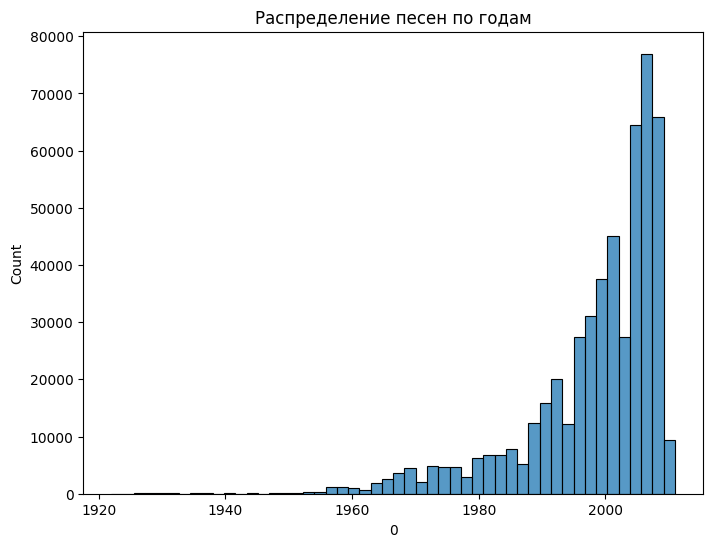

In [77]:
plt.figure(figsize=(8, 6))
sns.histplot(x=df.iloc[:, 0], bins=50)
plt.title("Распределение песен по годам");

Большинство треков приходится на 2000+ год.
Разделяем данные на тренировочную и тестовую выборку

In [78]:
train_data = df[:int(len(df) * 0.8)]
test_data = df[int(len(df) * 0.8):]

In [79]:
if torch.cuda.is_available():
  device = torch.device('cuda')
else:
  device = torch.device('cpu')

device

device(type='cuda')

Кастомный класс для предобработки данных

In [80]:
class CreateDataset(Dataset):
  def __init__(self, df, scaler, is_train, transforms=None):
    self.transforms = transforms
    self.X = df.drop(0, axis=1).values.astype(np.float32)
    self.y = df.iloc[:, 0].values.astype(np.float32)

    if is_train:
      self.X = scaler.fit_transform(self.X)
    else:
      self.X = scaler.transform(self.X)

    self.X = torch.FloatTensor(self.X)
    self.y = torch.FloatTensor(self.y)

  def __len__(self):
    return len(self.X)

  def __getitem__(self, idx):
    sample, target = self.X[idx], self.y[idx]

    if self.transforms:
      sample = self.transforms(sample)

    return sample, target


Тут разбиваем данные на батчи

In [81]:
scaler = StandardScaler()

num_batches = 256

train_data = CreateDataset(df=train_data, scaler=scaler, is_train=True)
test_data = CreateDataset(df=test_data, scaler=scaler, is_train=False)

train_dl = DataLoader(train_data, batch_size=num_batches)
test_dl = DataLoader(test_data, batch_size=num_batches)

In [82]:
len(train_dl), len(test_dl)

(1611, 403)

Реализуем функцию потерь mse loss с прямым проходом и функцией обратного распространения

In [83]:
class MyMSELoss():
  def __init__(self):
    self.y_pred = None
    self.y_real = None

  def forward(self, y_pred, y_real):
    self.y_pred = y_pred
    self.y_real = y_real
    loss = ((y_pred - y_real) ** 2).mean()
    return loss


Создаем алгоритм ГС

In [84]:
class MyAdam:
    def __init__(self, params, lr, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.params = params

        self.m = [torch.zeros_like(p, requires_grad=False) for p in params]
        self.v = [torch.zeros_like(p, requires_grad=False) for p in params]
        self.t = 0

    @torch.no_grad()
    def step(self, grads):
        self.t += 1

        bias_corr1 = 1.0 - self.beta1 ** self.t
        bias_corr2 = 1.0 - self.beta2 ** self.t
        lr = self.lr * (bias_corr2 ** 0.5) / bias_corr1

        for i in range(len(self.params)):
            g = grads[i]

            self.m[i].mul_(self.beta1).add_(g, alpha=1.0 - self.beta1)
            self.v[i].mul_(self.beta2).addcmul_(g, g, value=1.0 - self.beta2)

            denom = self.v[i].sqrt().add_(self.eps)
            step = self.m[i].div(denom)

            self.params[i].add_(step, alpha=-lr)

    @torch.no_grad()
    def zero_grad(self, set_to_none=False):
        for p in self.params:
            if p.grad is not None:
                if set_to_none:
                    p.grad = None
                else:
                    if p.grad.grad_fn is not None:
                        p.grad.detach_()
                    else:
                        p.grad.zero_()

Валидация с подсчетом MSE

In [85]:
def validate(data, model):
  model.eval()
  sum_mse = 0
  size = 0
  criterion = MyMSELoss()

  with torch.no_grad():
    for i, (X, y) in enumerate(test_dl):
      X = X.to(device)
      y = y.to(device)

      size += X.size(0)
      pred = model(X)
      pred = pred.squeeze()
      mse = criterion.forward(pred, y)
      sum_mse += mse.item()

  return round(np.sqrt(sum_mse / size), 2)


Создание полносвязной нейронной сети (количество слоев произвольное, единичка в конце для задачи регрессии)

In [86]:
class FCNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(90, 256),
        nn.ReLU(),
        nn.Linear(256, 128),
        nn.ReLU(),
        nn.Linear(128, 1)
    )

  def forward(self, x):
    out = self.model(x)
    return out
model = FCNN()
summary(model, input_size=(num_batches, 1, 90))

Layer (type:depth-idx)                   Output Shape              Param #
FCNN                                     [256, 1, 1]               --
├─Sequential: 1-1                        [256, 1, 1]               --
│    └─Linear: 2-1                       [256, 1, 256]             23,296
│    └─ReLU: 2-2                         [256, 1, 256]             --
│    └─Linear: 2-3                       [256, 1, 128]             32,896
│    └─ReLU: 2-4                         [256, 1, 128]             --
│    └─Linear: 2-5                       [256, 1, 1]               129
Total params: 56,321
Trainable params: 56,321
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 14.42
Input size (MB): 0.09
Forward/backward pass size (MB): 0.79
Params size (MB): 0.23
Estimated Total Size (MB): 1.11

In [87]:
model

FCNN(
  (model): Sequential(
    (0): Linear(in_features=90, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=1, bias=True)
  )
)

Задаем процесс тренировки с подсчетом лосса на трейне и RMSE на валидации

In [88]:
def train(lr=0.001, device=device, epochs=10):
  model = FCNN().to(device)
  optimizer = MyAdam(list(model.parameters()), lr=lr)
  lf = MyMSELoss()
  rmse_list = []
  loss_list = []

  for i in range(epochs):
    model.train()
    print(f'Начало эпохи {i + 1}...')
    sum_loss = 0
    for i, (X, y) in enumerate(train_dl):
      X = X.to(device)
      y = y.to(device)

      optimizer.zero_grad()

      pred = model(X)
      pred = pred.squeeze()
      loss = lf.forward(pred, y)
      sum_loss += loss.item()

      loss.backward()
      grads = [p.grad for p in model.parameters()]
      optimizer.step(grads)

    loss_list.append(sum_loss / num_batches)

    print("Валидация...")
    metric = float(validate(test_dl, model))
    print(f'RMSE: {metric}, loss={round(sum_loss / num_batches, 2)}')
    rmse_list.append(metric)

  fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))
  axes[0].plot(rmse_list)
  axes[0].set_title("RMSE на тесте")
  axes[1].plot(loss_list, 'r')
  axes[1].set_title("Лосс на трейне")



Начало эпохи 1...
Валидация...
RMSE: 14.18, loss=2821066.73
Начало эпохи 2...
Валидация...
RMSE: 3.76, loss=114079.97
Начало эпохи 3...
Валидация...
RMSE: 1.53, loss=7954.62
Начало эпохи 4...
Валидация...
RMSE: 1.1, loss=2141.94
Начало эпохи 5...
Валидация...
RMSE: 1.36, loss=1899.1
Начало эпохи 6...
Валидация...
RMSE: 1.2, loss=1949.04
Начало эпохи 7...
Валидация...
RMSE: 1.11, loss=1883.85
Начало эпохи 8...
Валидация...
RMSE: 1.05, loss=1803.36
Начало эпохи 9...
Валидация...
RMSE: 1.03, loss=1731.63
Начало эпохи 10...
Валидация...
RMSE: 0.9, loss=1742.94


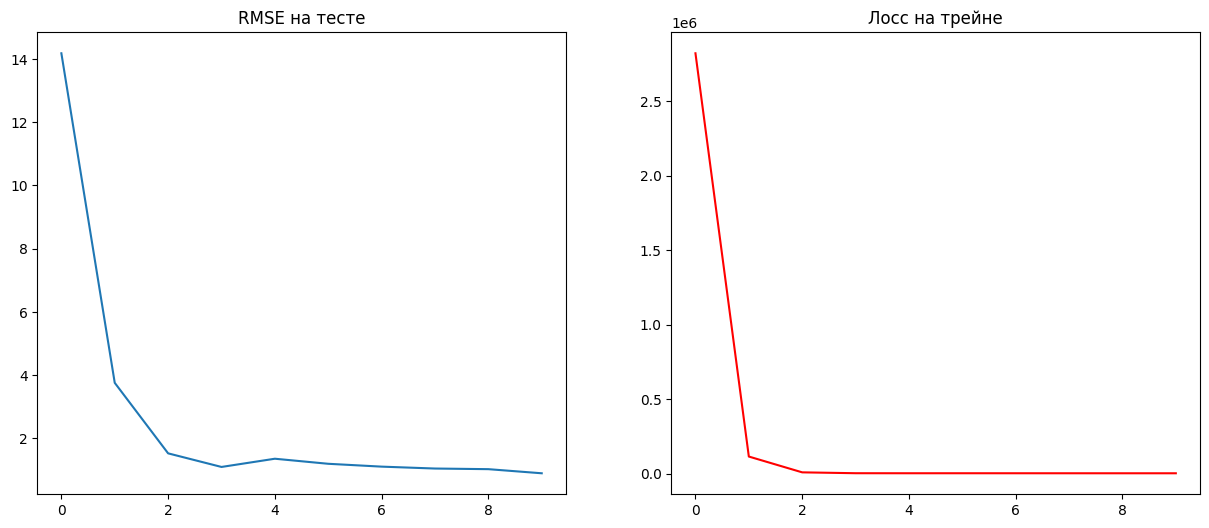

In [89]:
train()